# Decision 04 - Calendar Definition with Official Ticker Lifecycle Evidence

**Fecha:** 2026-02-11  
**Autor:** Alex  
**Proposito:** construir la verdad temporal por ticker usando evidencia oficial (exchange/SEC), y reconciliarla contra los datos observados locales.  
**Estado:** DRAFT

Este notebook restaura el flujo oficial por ticker:
1. evidencia oficial ->
2. lifecycle (`list_date`, `delist_date`) ->
3. expected trading days por ticker ->
4. comparativa con datos observados.


## Que hace este notebook (explicacion didactica y cientifica)

`04_calendar_definition.ipynb` define la **verdad temporal oficial por ticker** y la contrasta contra lo observado en los datasets locales.

La logica cientifica del notebook es:

1. Fijar configuracion reproducible (simbolos, ventana temporal, version de corrida, rutas de evidencia oficial y salida en `runs`).
2. Construir calendario oficial de mercado (`XNYS`) como universo base de dias habiles de sesion.
3. Cargar evidencia oficial por ticker (`official_ticker_events.csv`), validar su esquema minimo y limpiar semantica (`listed`, `delisted`, `halted`, etc.).
4. Construir (o cargar) el lifecycle oficial por ticker (`list_date`, `delist_date`) y dossier trazable con fuentes.
5. Derivar `expected trading days` por ticker = interseccion entre calendario oficial de mercado y ventana lifecycle del ticker.
6. Escanear dias observados en cache local por dataset (`quotes_p95`, `trades_ticks_2004_2018`, `trades_ticks_2019_2025`).
7. Reconciliar esperado vs observado y cuantificar metricas por ticker-dataset:
   - `coverage_ratio`
   - `missing_n_days`
   - `extra_n_days`
   - `weekend_extra_n_days`
   - `partition_drift_flag`
8. Aplicar politica de gate por dataset (gating vs informational) y consolidar `overall_status` (PASS/WARN/FAIL).
9. Exportar evidencia auditable (parquets + decision JSON) para consumo de etapas posteriores.

Interpretacion conceptual:
- Este notebook no valida alpha; valida consistencia calendario/lifecycle.
- Si falla aqui, toda inferencia temporal downstream (sesiones, cobertura, microestructura) queda potencialmente sesgada.


## Step 1 - Setup y trazabilidad

Que hacemos:
- Definir simbolos y rango temporal global.
- Definir rutas de evidencia oficial.
- Definir salida versionada en `runs/data_quality`.

Por que:
- La decision de calidad temporal debe ser auditable y reproducible.


In [1]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
import uuid
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import polars as pl

NOTEBOOK_ID = "04_calendar_definition"
try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available:", e)

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.data.calendar_reconciliation import build_expected_trading_days, status_from_coverage

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
RUNS_DIR = Path(os.getenv("RUNS_DIR", PROJECT_ROOT / "runs")).resolve()
OUT_DIR = RUNS_DIR / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "ticker_docs").mkdir(parents=True, exist_ok=True)

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT).decode().strip()
except Exception:
    git_commit = "<unknown>"

SYMBOLS = ["AABA"]
START_DATE = "2004-01-01"
END_DATE = "2025-12-31"
CALENDAR_NAME = "XNYS"
STRICT_OFFICIAL_CALENDAR = True

OFFICIAL_EVENTS_CSV = PROJECT_ROOT / "data" / "reference" / "official_ticker_events.csv"
OFFICIAL_LIFECYCLE_CSV = PROJECT_ROOT / "data" / "reference" / "official_lifecycle_compiled.csv"
REQUIRE_OFFICIAL_EVIDENCE = True

DATA_ROOT = Path(os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")).resolve()
MAX_FILES_PER_DATASET = 50000

DATASET_ORDER = ["quotes_p95", "trades_ticks_2004_2018", "trades_ticks_2019_2025"]
NON_GATING_DATASETS = {"quotes_p95"}
QUOTES_P95_MIN_COVERAGE = 0.25

print("Run ID:", RUN_ID)
print("Out dir:", OUT_DIR)
print("Git commit:", git_commit)
print("Symbols:", SYMBOLS)
print("Official events:", OFFICIAL_EVENTS_CSV)
print("Official lifecycle:", OFFICIAL_LIFECYCLE_CSV)


Run ID: 20260211_191200_35ebd0d1
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1
Git commit: 4f912b58d2cf5fe825b7735ab3ae668ce0781991
Symbols: ['AABA']
Official events: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv
Official lifecycle: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv


## Step 2 - Calendario oficial de mercado

Que hacemos:
- Construir calendario oficial XNYS.

Por que:
- Este calendario define los dias validos de sesion del mercado.


In [2]:
cal = build_expected_trading_days(
    start_date=START_DATE,
    end_date=END_DATE,
    calendar_name=CALENDAR_NAME,
    strict_official=STRICT_OFFICIAL_CALENDAR,
)

expected_market_days = pd.DatetimeIndex(cal.dates).normalize()
calendar_source = cal.source
calendar_notes = cal.notes

print("Calendar source:", calendar_source)
print("Expected market days:", len(expected_market_days))
if calendar_notes:
    for n in calendar_notes:
        print(" -", n)


Calendar source: exchange_calendars:XNYS
Expected market days: 5003


## Step 3 - Evidencia oficial por ticker y lifecycle

Que hacemos:
- Cargar `official_ticker_events.csv` (evidencia oficial documentada por ticker: exchange notices / SEC filings).
- Validar columnas y semantica minima.
- Cargar o reconstruir lifecycle (`list_date`, `delist_date`).
- Generar dossier markdown por ticker con URLs de evidencia.

Importante (estado actual):
- Este notebook no descarga automaticamente de internet en runtime.
- Consume `official_ticker_events.csv` y `official_lifecycle_compiled.csv` desde `data/reference`.
- El CSV de lifecycle se construye con `scripts/build_official_lifecycle.py` a partir del CSV de eventos oficiales.

Por que:
- Sin evidencia oficial por ticker, la reconciliacion de cobertura no es defendible.


In [3]:
REQUIRED_EVENT_COLS = {
    "ticker", "cik", "event_type", "event_date", "source_name",
    "source_doc_type", "source_url", "source_title", "notes"
}


def load_official_events(events_csv: Path) -> pl.DataFrame:
    if not events_csv.exists():
        raise FileNotFoundError(f"Missing official events file: {events_csv}")
    ev = pl.read_csv(events_csv)
    missing = REQUIRED_EVENT_COLS - set(ev.columns)
    if missing:
        raise ValueError(f"Missing required columns in events csv: {sorted(missing)}")

    ev = (
        ev.with_columns([
            pl.col("ticker").cast(pl.Utf8).str.strip_chars().str.to_uppercase(),
            pl.col("cik").cast(pl.Utf8).str.strip_chars(),
            pl.col("event_type").cast(pl.Utf8).str.strip_chars().str.to_lowercase(),
            pl.col("event_date").cast(pl.Utf8).str.strptime(pl.Date, strict=False),
            pl.col("source_name").cast(pl.Utf8).str.strip_chars(),
            pl.col("source_doc_type").cast(pl.Utf8).str.strip_chars(),
            pl.col("source_url").cast(pl.Utf8).str.strip_chars(),
            pl.col("source_title").cast(pl.Utf8).str.strip_chars(),
            pl.col("notes").cast(pl.Utf8),
        ])
        .filter(pl.col("event_date").is_not_null())
        .filter(pl.col("event_type").is_in(["listed", "delisted", "renamed", "halted", "suspended"]))
        .filter(pl.col("source_url").str.starts_with("http"))
    )

    if ev.height == 0:
        raise ValueError("No valid official events found after validation")
    return ev


def build_lifecycle_from_events(events: pl.DataFrame) -> pl.DataFrame:
    listed = (
        events.filter(pl.col("event_type") == "listed")
        .group_by(["ticker", "cik"])
        .agg(pl.col("event_date").min().alias("list_date"))
    )

    delisted = (
        events.filter(pl.col("event_type").is_in(["delisted", "suspended", "halted"]))
        .group_by(["ticker", "cik"])
        .agg(pl.col("event_date").max().alias("delist_date"))
    )

    evidence = (
        events.group_by(["ticker", "cik"])
        .agg([
            pl.len().alias("evidence_count"),
            pl.col("source_name").n_unique().alias("source_count"),
            pl.col("source_doc_type").unique().alias("source_doc_types"),
        ])
    )

    lc = (
        listed.join(delisted, on=["ticker", "cik"], how="left")
        .join(evidence, on=["ticker", "cik"], how="left")
        .with_columns([
            pl.col("list_date").cast(pl.Date),
            pl.col("delist_date").cast(pl.Date),
            pl.when(pl.col("delist_date").is_not_null() & (pl.col("delist_date") < pl.col("list_date")))
              .then(pl.lit(True)).otherwise(pl.lit(False)).alias("date_order_invalid"),
        ])
        .filter(~pl.col("date_order_invalid"))
        .drop("date_order_invalid")
        .sort(["ticker", "cik"])
    )
    return lc


official_events = load_official_events(OFFICIAL_EVENTS_CSV)
official_events = official_events.filter(pl.col("ticker").is_in([s.upper() for s in SYMBOLS]))

if official_events.height == 0 and REQUIRE_OFFICIAL_EVIDENCE:
    raise ValueError("No official evidence found for requested symbols")

if OFFICIAL_LIFECYCLE_CSV.exists():
    official_lifecycle = pl.read_csv(OFFICIAL_LIFECYCLE_CSV).with_columns([
        pl.col("ticker").cast(pl.Utf8).str.to_uppercase(),
        pl.col("list_date").cast(pl.Utf8).str.strptime(pl.Date, strict=False),
        pl.col("delist_date").cast(pl.Utf8).str.strptime(pl.Date, strict=False),
    ])
    official_lifecycle = official_lifecycle.filter(pl.col("ticker").is_in([s.upper() for s in SYMBOLS]))
else:
    official_lifecycle = build_lifecycle_from_events(official_events)

for sym in [s.upper() for s in SYMBOLS]:
    evs = official_events.filter(pl.col("ticker") == sym).sort("event_date")
    doc_path = OUT_DIR / "ticker_docs" / f"{sym}_official_evidence.md"
    lines = [
        f"# Official Evidence - {sym}\n",
        "\n",
        f"Generated UTC: {datetime.now(timezone.utc).isoformat()}\n",
        "\n",
        "## Evidence Rows\n",
    ]
    if evs.height == 0:
        lines.append("No official evidence rows found for this ticker.\n")
    else:
        for r in evs.to_dicts():
            lines.append(
                f"- {r['event_date']} | {r['event_type']} | {r['source_name']} | {r['source_doc_type']} | {r['source_title']} | {r['source_url']}\n"
            )
    doc_path.write_text("".join(lines), encoding="utf-8")

official_meta = (
    pl.DataFrame({"ticker": [s.upper() for s in SYMBOLS]})
    .join(
        official_events.group_by("ticker").agg([
            pl.len().alias("official_evidence_rows"),
            pl.col("source_name").n_unique().alias("official_source_count"),
            pl.col("source_url").n_unique().alias("official_url_count"),
        ]),
        on="ticker",
        how="left",
    )
    .join(
        official_lifecycle.select(["ticker", "list_date", "delist_date"]),
        on="ticker",
        how="left",
    )
    .with_columns([
        pl.col("official_evidence_rows").fill_null(0),
        pl.col("official_source_count").fill_null(0),
        pl.col("official_url_count").fill_null(0),
        (pl.col("official_evidence_rows") > 0).alias("official_evidence_found"),
        pl.col("list_date").is_not_null().alias("official_lifecycle_found"),
    ])
    .sort("ticker")
)

print("Official events rows:", official_events.height)
print("Official lifecycle rows:", official_lifecycle.height)
official_meta


official_sources = (
    official_events
    .select(["ticker", "source_name", "source_doc_type", "source_url", "source_title"])
    .unique()
    .sort(["ticker", "source_name"])
)
print("Official source rows:", official_sources.height)
official_sources


Official events rows: 3
Official lifecycle rows: 1
Official source rows: 3


ticker,source_name,source_doc_type,source_url,source_title
str,str,str,str,str
"""AABA""","""Nasdaq""","""Exchange Notice""","""https://altaba.com/press-relea…","""Nasdaq halt and suspension pro…"
"""AABA""","""Nasdaq""","""Exchange Notice""","""https://altaba.com/press-relea…","""Altaba press release mentionin…"
"""AABA""","""SEC""","""Form 8-K""","""https://www.sec.gov/Archives/e…","""8-K related to suspension and …"


## Step 4 - Construir expected days por ticker

Que hacemos:
- Interseccion entre calendario oficial de mercado y ventana lifecycle por ticker.

Por que:
- Define los dias esperados reales para ese ticker, no solo para el mercado.


In [4]:
market_set = set(pd.to_datetime(expected_market_days).date)

lifecycle_map = {row["ticker"]: row for row in official_lifecycle.to_dicts()}
expected_by_symbol = {}
summary_rows = []
end_date_obj = pd.to_datetime(END_DATE).date()

for sym in [s.upper() for s in SYMBOLS]:
    row = lifecycle_map.get(sym)
    if row is None or row.get("list_date") is None:
        exp = []
        has_lifecycle = False
        lo = None
        hi = None
    else:
        has_lifecycle = True
        lo = row["list_date"]
        hi = row.get("delist_date") or end_date_obj
        exp = sorted([d for d in market_set if lo <= d <= hi])

    expected_by_symbol[sym] = set(exp)
    summary_rows.append({
        "ticker": sym,
        "has_lifecycle": has_lifecycle,
        "list_date": str(lo) if lo is not None else None,
        "delist_date": str(hi) if hi is not None else None,
        "expected_n_days": int(len(exp)),
    })

expected_summary = pl.DataFrame(summary_rows).sort("ticker")
expected_summary


ticker,has_lifecycle,list_date,delist_date,expected_n_days
str,bool,str,str,i64
"""AABA""",true,"""2017-06-16""","""2019-10-02""",578


## Step 5 - Escaneo observado por ticker

Que hacemos:
- Escanear particiones locales por ticker y dataset.

Por que:
- Necesitamos observados por ticker-dataset-dia para reconciliar contra expected.


In [5]:
QUOTES_RE = re.compile(r"^year=(?P<year>\d{4})/month=(?P<month>\d{2})/day=(?P<day>\d{2})/quotes\.parquet$")
TRADES_RE = re.compile(r"^year=(?P<year>\d{4})/month=(?P<month>\d{2})/day=(?P<day>\d{4}-\d{2}-\d{2})/(?P<session>[^/]+)\.parquet$")


def scan_symbol_dataset_days(data_root: Path, symbol: str, dataset_root: str, max_files: int) -> list[dict]:
    rows = []
    base = data_root / dataset_root / symbol.upper()
    if not base.exists():
        return rows

    n = 0
    for fp in base.rglob("*.parquet"):
        rel = fp.relative_to(base).as_posix()

        if dataset_root.startswith("quotes"):
            m = QUOTES_RE.match(rel)
            if not m:
                continue
            d = f"{m.group('year')}-{m.group('month')}-{m.group('day')}"
            rows.append({"dataset": "quotes_p95", "ticker": symbol.upper(), "date": d})

        elif dataset_root.startswith("trades_ticks"):
            m = TRADES_RE.match(rel)
            if not m:
                continue
            d = m.group("day")
            rows.append({"dataset": dataset_root, "ticker": symbol.upper(), "date": d})

        n += 1
        if max_files is not None and n >= max_files:
            break

    return rows


raw_rows = []
for sym in [s.upper() for s in SYMBOLS]:
    for ds_root in ["quotes_p95", "quotes_p95_2004_2018", "quotes_p95_2019_2025", "trades_ticks_2004_2018", "trades_ticks_2019_2025"]:
        raw_rows.extend(scan_symbol_dataset_days(DATA_ROOT, sym, ds_root, MAX_FILES_PER_DATASET))

if raw_rows:
    observed_daily = (
        pl.DataFrame(raw_rows)
        .group_by(["dataset", "ticker", "date"]).len()
        .rename({"len": "file_count"})
        .with_columns(pl.col("date").str.strptime(pl.Date, strict=False))
        .sort(["ticker", "dataset", "date"])
    )
else:
    observed_daily = pl.DataFrame(schema={"dataset": pl.Utf8, "ticker": pl.Utf8, "date": pl.Date, "file_count": pl.Int64})

print("Observed rows:", observed_daily.height)
observed_daily.head(10)


Observed rows: 828


dataset,ticker,date,file_count
str,str,date,u32
"""quotes_p95""","""AABA""",2019-01-02,2
"""quotes_p95""","""AABA""",2019-01-03,2
"""quotes_p95""","""AABA""",2019-01-04,2
"""quotes_p95""","""AABA""",2019-01-07,2
"""quotes_p95""","""AABA""",2019-01-08,2
"""quotes_p95""","""AABA""",2019-01-09,2
"""quotes_p95""","""AABA""",2019-01-10,2
"""quotes_p95""","""AABA""",2019-01-11,2
"""quotes_p95""","""AABA""",2019-01-14,2


## Step 6 - Reconciliacion con politica por dataset

Politica aplicada:
- `quotes_p95` es informativo (no bloqueante).
- `trades_ticks_*` es bloqueante, salvo drift de particion claramente detectado.


In [6]:
records = []
anomaly_rows = []

for sym in [s.upper() for s in SYMBOLS]:
    exp_set = expected_by_symbol.get(sym, set())
    has_official = bool(official_meta.filter(pl.col("ticker") == sym)["official_lifecycle_found"].to_list()[0]) if official_meta.height > 0 else False

    dataset_obs = {}
    for ds in DATASET_ORDER:
        obs = observed_daily.filter((pl.col("ticker") == sym) & (pl.col("dataset") == ds))
        dataset_obs[ds] = set(obs["date"].to_list())

    obs_early = dataset_obs.get("trades_ticks_2004_2018", set())
    obs_late = dataset_obs.get("trades_ticks_2019_2025", set())
    late_has_pre2019 = any(d.year <= 2018 for d in obs_late)
    early_window_expected = any(d.year <= 2018 for d in exp_set)
    partition_drift_flag = (len(obs_early) == 0) and late_has_pre2019

    for ds in DATASET_ORDER:
        obs_set = dataset_obs.get(ds, set())

        overlap = exp_set & obs_set
        missing = sorted(exp_set - obs_set)
        extra = sorted(obs_set - exp_set)
        cov = float(len(overlap) / len(exp_set)) if exp_set else 0.0
        weekend_extra_n = int(sum(1 for d in extra if d.weekday() >= 5))

        if not has_official:
            status = "FAIL"
            gate_role = "gating"
        elif ds in NON_GATING_DATASETS:
            gate_role = "informational"
            status = "WARN" if cov < QUOTES_P95_MIN_COVERAGE else "PASS"
        elif ds == "trades_ticks_2004_2018" and partition_drift_flag and early_window_expected:
            gate_role = "informational"
            status = "PASS"
        else:
            gate_role = "gating"
            status = status_from_coverage(cov, len(missing), len(extra))

        records.append({
            "ticker": sym,
            "dataset": ds,
            "gate_role": gate_role,
            "has_official_lifecycle": has_official,
            "expected_n_days": int(len(exp_set)),
            "observed_n_days": int(len(obs_set)),
            "overlap_n_days": int(len(overlap)),
            "coverage_ratio": cov,
            "missing_n_days": int(len(missing)),
            "extra_n_days": int(len(extra)),
            "weekend_extra_n_days": weekend_extra_n,
            "partition_drift_flag": bool(partition_drift_flag),
            "missing_sample": [str(x) for x in missing[:15]],
            "extra_sample": [str(x) for x in extra[:15]],
            "status": status,
        })

        miss_year = {}
        for d in missing:
            miss_year[d.year] = miss_year.get(d.year, 0) + 1
        extra_year = {}
        for d in extra:
            extra_year[d.year] = extra_year.get(d.year, 0) + 1

        for y, n in sorted(miss_year.items()):
            anomaly_rows.append({"ticker": sym, "dataset": ds, "anomaly_type": "missing", "year": int(y), "count": int(n)})
        for y, n in sorted(extra_year.items()):
            anomaly_rows.append({"ticker": sym, "dataset": ds, "anomaly_type": "extra", "year": int(y), "count": int(n)})

recon = pl.DataFrame(records).sort(["ticker", "dataset"])
if anomaly_rows:
    anomaly_yearly = pl.DataFrame(anomaly_rows).sort(["ticker", "dataset", "year", "anomaly_type"])
else:
    anomaly_yearly = pl.DataFrame(schema={"ticker": pl.Utf8, "dataset": pl.Utf8, "anomaly_type": pl.Utf8, "year": pl.Int64, "count": pl.Int64})

recon


ticker,dataset,gate_role,has_official_lifecycle,expected_n_days,observed_n_days,overlap_n_days,coverage_ratio,missing_n_days,extra_n_days,weekend_extra_n_days,partition_drift_flag,missing_sample,extra_sample,status
str,str,str,bool,i64,i64,i64,f64,i64,i64,i64,bool,list[str],list[str],str
"""AABA""","""quotes_p95""","""informational""",true,578,181,181,0.313149,397,0,0,true,"[""2017-06-16"", ""2017-06-19"", … ""2017-07-07""]",[],"""PASS"""
"""AABA""","""trades_ticks_2004_2018""","""informational""",true,578,0,0,0.0,578,0,0,true,"[""2017-06-16"", ""2017-06-19"", … ""2017-07-07""]",[],"""PASS"""
"""AABA""","""trades_ticks_2019_2025""","""gating""",true,578,647,577,0.99827,1,70,64,true,"[""2017-06-16""]","[""2017-07-01"", ""2017-07-15"", … ""2017-12-30""]","""WARN"""


## Step 7 - Diagnostico visual

Graficos verticales para lectura clara:
1. cobertura por dataset,
2. faltantes por anio,
3. extras por anio,
4. extras en fin de semana.


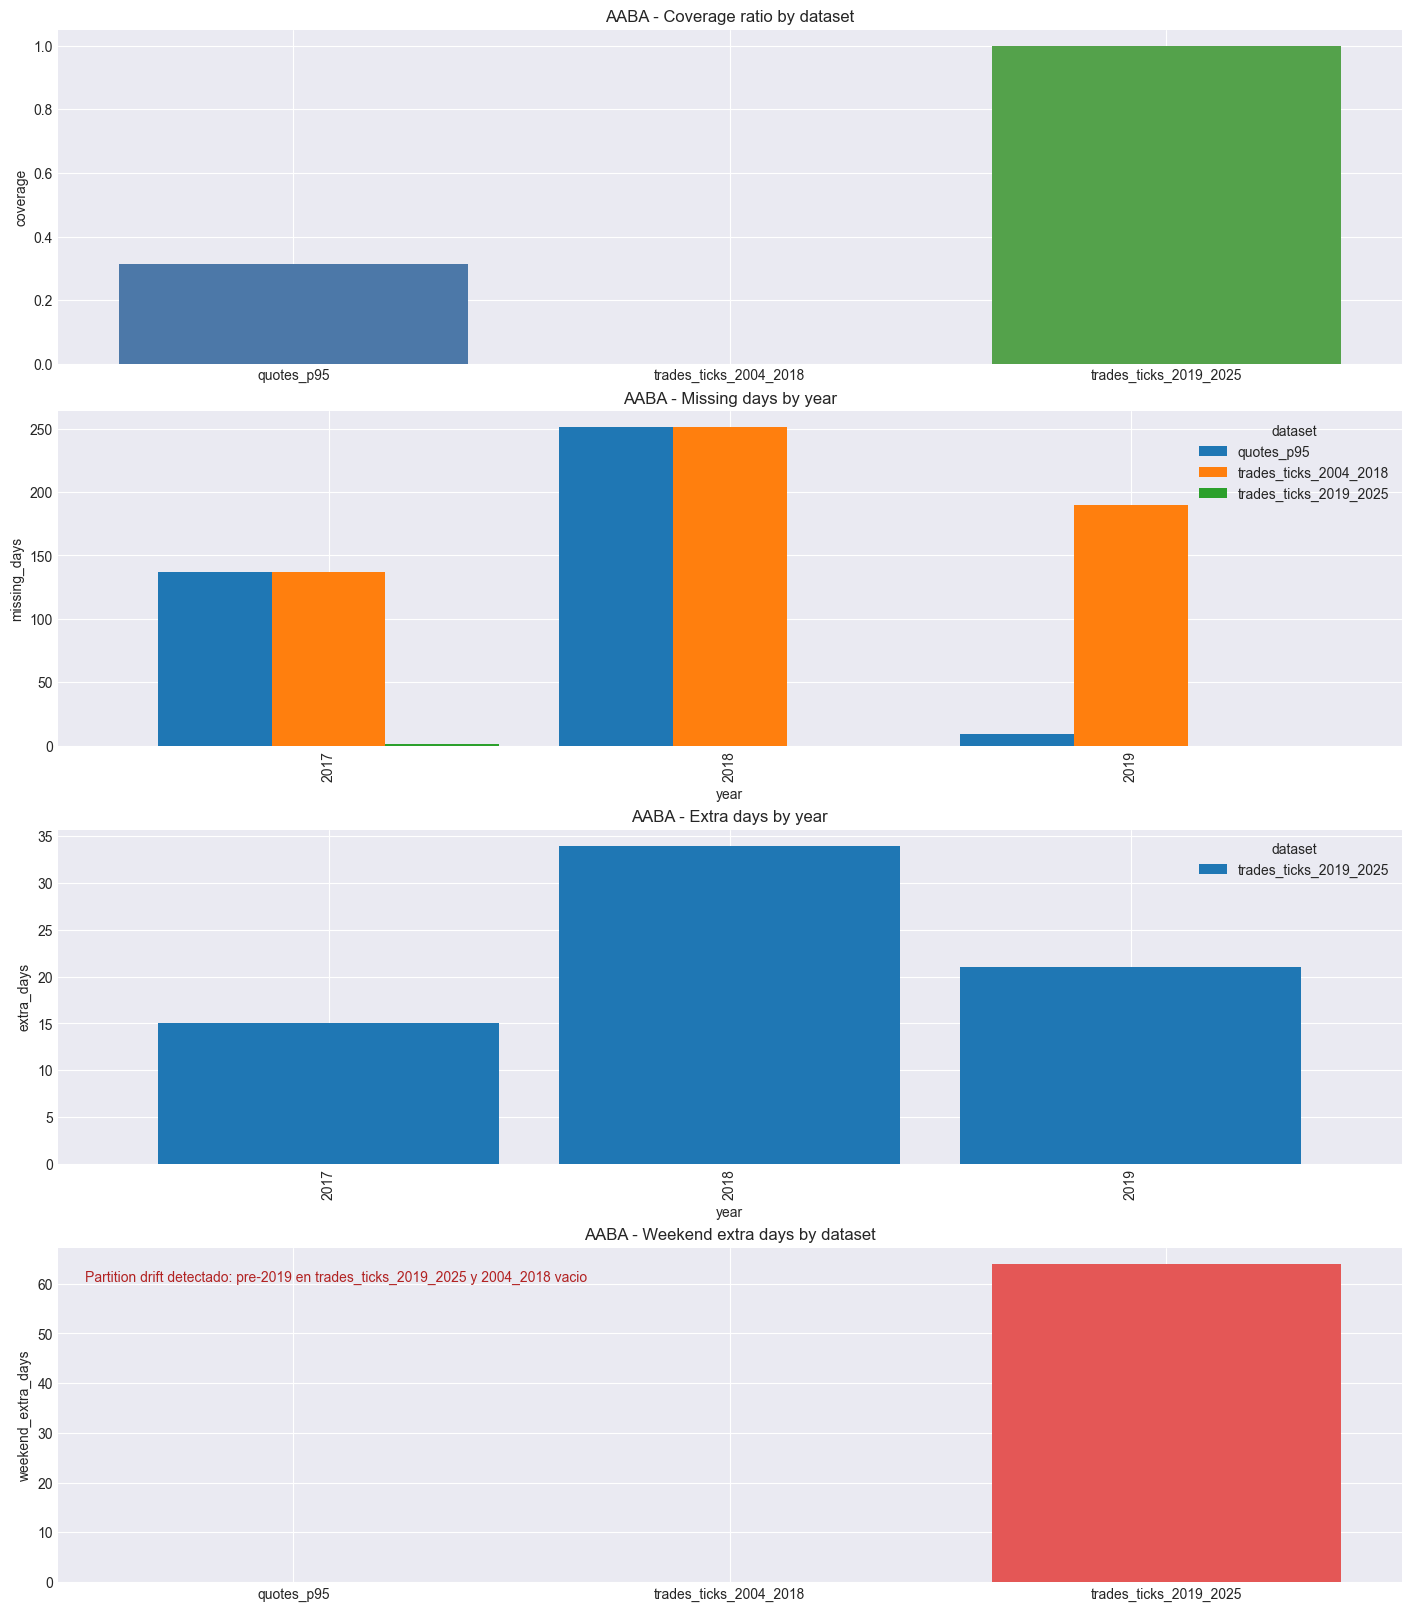

In [7]:
if plt is not None and recon.height > 0:
    plt.style.use("seaborn-v0_8-darkgrid")

    for sym in [s.upper() for s in SYMBOLS]:
        r = pd.DataFrame(recon.filter(pl.col("ticker") == sym).to_dicts())
        ay = pd.DataFrame(anomaly_yearly.filter(pl.col("ticker") == sym).to_dicts()) if anomaly_yearly.height > 0 else None
        if r.empty:
            continue

        fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 16), constrained_layout=True)

        colors = ["#4c78a8", "#f58518", "#54a24b"]
        axes[0].bar(r["dataset"], r["coverage_ratio"], color=colors[:len(r)])
        axes[0].set_ylim(0, 1.05)
        axes[0].set_title(f"{sym} - Coverage ratio by dataset")
        axes[0].set_ylabel("coverage")

        if ay is not None and not ay.empty:
            m = ay[ay["anomaly_type"] == "missing"].pivot_table(index="year", columns="dataset", values="count", aggfunc="sum").fillna(0)
            m.plot(kind="bar", ax=axes[1], width=0.85)
            axes[1].set_title(f"{sym} - Missing days by year")
            axes[1].set_ylabel("missing_days")
        else:
            axes[1].text(0.5, 0.5, "No missing anomalies", ha="center", va="center")
            axes[1].set_axis_off()

        if ay is not None and not ay.empty:
            e = ay[ay["anomaly_type"] == "extra"].pivot_table(index="year", columns="dataset", values="count", aggfunc="sum").fillna(0)
            if not e.empty:
                e.plot(kind="bar", ax=axes[2], width=0.85)
                axes[2].set_title(f"{sym} - Extra days by year")
                axes[2].set_ylabel("extra_days")
            else:
                axes[2].text(0.5, 0.5, "No extra anomalies", ha="center", va="center")
                axes[2].set_axis_off()
        else:
            axes[2].text(0.5, 0.5, "No extra anomalies", ha="center", va="center")
            axes[2].set_axis_off()

        axes[3].bar(r["dataset"], r["weekend_extra_n_days"], color="#e45756")
        axes[3].set_title(f"{sym} - Weekend extra days by dataset")
        axes[3].set_ylabel("weekend_extra_days")

        drift = bool(r["partition_drift_flag"].any())
        if drift:
            axes[3].text(0.02, 0.90, "Partition drift detectado: pre-2019 en trades_ticks_2019_2025 y 2004_2018 vacio", transform=axes[3].transAxes, fontsize=10, color="#b22222")

        plt.show()


## Step 8 - Export de artefactos


In [8]:
if recon.height > 0:
    gating = recon.filter(pl.col("gate_role") == "gating")
else:
    gating = recon

overall = "PASS"
statuses = gating["status"].to_list() if gating.height > 0 else ["FAIL"]
if "FAIL" in statuses:
    overall = "FAIL"
elif "WARN" in statuses:
    overall = "WARN"

decision = {
    "decision_id": "calendar_official_lifecycle_reconciliation_v6",
    "version": "6.0.0",
    "as_of_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "calendar_name": CALENDAR_NAME,
    "calendar_source": calendar_source,
    "symbols": [s.upper() for s in SYMBOLS],
    "official_events_csv": str(OFFICIAL_EVENTS_CSV),
    "official_lifecycle_csv": str(OFFICIAL_LIFECYCLE_CSV),
    "dataset_policy": {
        "non_gating": sorted(list(NON_GATING_DATASETS)),
        "quotes_p95_min_coverage": QUOTES_P95_MIN_COVERAGE,
    },
    "overall_status": overall,
    "records": recon.to_dicts(),
}

official_meta.write_parquet(OUT_DIR / "official_exchange_meta.parquet")
official_lifecycle.write_parquet(OUT_DIR / "official_lifecycle.parquet")
official_events.write_parquet(OUT_DIR / "official_ticker_events.parquet")
observed_daily.write_parquet(OUT_DIR / "calendar_observed_daily_by_ticker.parquet")
recon.write_parquet(OUT_DIR / "calendar_reconciliation_by_ticker.parquet")
anomaly_yearly.write_parquet(OUT_DIR / "calendar_anomaly_yearly.parquet")

with open(OUT_DIR / "calendar_reconciliation_decision.json", "w", encoding="utf-8") as f:
    json.dump(decision, f, indent=2)

print("Saved:", OUT_DIR / "official_exchange_meta.parquet")
print("Saved:", OUT_DIR / "official_lifecycle.parquet")
print("Saved:", OUT_DIR / "official_ticker_events.parquet")
print("Saved:", OUT_DIR / "calendar_observed_daily_by_ticker.parquet")
print("Saved:", OUT_DIR / "calendar_reconciliation_by_ticker.parquet")
print("Saved:", OUT_DIR / "calendar_anomaly_yearly.parquet")
print("Saved:", OUT_DIR / "calendar_reconciliation_decision.json")
print("Saved ticker docs:", OUT_DIR / "ticker_docs")
print("OVERALL (gating datasets):", overall)


Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\official_exchange_meta.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\official_lifecycle.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\official_ticker_events.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\calendar_observed_daily_by_ticker.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\calendar_reconciliation_by_ticker.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\calendar_anomaly_yearly.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1\calendar_reconciliation_decision.json
S

### Interpretacion final de resultados (criterio operativo)

Lectura cientifica de la salida del notebook:

- `overall_status` se calcula solo con datasets `gating`; un `FAIL` aqui implica NO-GO para la capa temporal.
- `coverage_ratio` alto con `missing_n_days` y `extra_n_days` bajos indica buena coherencia calendario-vs-datos.
- `extra_n_days` en fines de semana (`weekend_extra_n_days`) sugiere ruido de particionado o problemas de fecha.
- `partition_drift_flag=True` identifica drift de particiones entre datasets historicos y recientes; puede reclasificar casos especificos como informativos.
- `quotes_p95` es informativo, no bloqueante; el gate fuerte recae en `trades_ticks_*` y presencia de lifecycle oficial defendible.

Artefactos clave para auditoria:
- `official_exchange_meta.parquet`
- `official_lifecycle.parquet`
- `official_ticker_events.parquet`
- `calendar_observed_daily_by_ticker.parquet`
- `calendar_reconciliation_by_ticker.parquet`
- `calendar_anomaly_yearly.parquet`
- `calendar_reconciliation_decision.json`

Conclusion metodologica:
este notebook establece la base temporal oficial y auditable del programa de integridad; sin esta base, las decisiones intradia no son defendibles en produccion.


## Nota operativa

En escalado (20 anios x miles de tickers):
- construir lifecycle por ticker antes de reconciliar,
- ejecutar por lotes de simbolos,
- persistir decision por lote y consolidar en un resumen maestro.
